# Explore here

In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/screen_time_mental_health (1).csv")

print(df.head())

   subject_id   sex  screen_time_index  est_leisure_screen_hours  \
0           1   Boy              3.333                      4.64   
1           2  Girl              3.333                      4.07   
2           3   Boy              3.333                      4.07   
3           4   Boy              4.333                      6.07   
4           5   Boy              1.667                      0.50   

   sleep_quality_index  avg_sleep_hours  midsleep_weekend_hours  \
0                 2.25             8.36                    4.58   
1                 2.50             7.31                    5.42   
2                 2.00             8.75                    5.50   
3                 1.50             8.17                    6.62   
4                 2.50             8.88                    4.12   

   social_jetlag_hours  bdi_total  depressed  
0                 1.92          6          0  
1                 2.25          7          0  
2                 2.62         27          1  


In [2]:
df.shape

(4810, 10)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4810 entries, 0 to 4809
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   subject_id                4810 non-null   int64  
 1   sex                       4810 non-null   str    
 2   screen_time_index         4810 non-null   float64
 3   est_leisure_screen_hours  4810 non-null   float64
 4   sleep_quality_index       4810 non-null   float64
 5   avg_sleep_hours           4810 non-null   float64
 6   midsleep_weekend_hours    4810 non-null   float64
 7   social_jetlag_hours       4810 non-null   float64
 8   bdi_total                 4810 non-null   int64  
 9   depressed                 4810 non-null   int64  
dtypes: float64(6), int64(3), str(1)
memory usage: 375.9 KB


Nuestro dataframe tiene 4810 observaciones y 10 variables. Para el modelo de regresión, vamos a tomar como variable dependiente 'bdi_total' y como predictoras todas las restantes a excepción de dos: 'subject_id', que no debería utilizarse como predictor porque es simplemente un identificador, y 'depressed', que tampoco conviene incluirlo si es una variable construida a partir de 'bdi_total', porque produciría fuga de información. Todas nuestras variables son numéricas menos una: 'sex', que es categórica. Por otro lado podemos ver que no hay valores nulos, y que el número de filas es de 4810, que corresponden al número de niños de entre 12 y 16 años consultados.

In [4]:
df = df.drop(columns=["subject_id", "depressed"])

**Excluímos ambas variables mencionadas del df**

In [5]:
df.duplicated().sum()

np.int64(0)

**Podemos corroborar que no hay duplicados.**

Las Variables significan:


subject_id: Identificador único de cada participante


sex:	Sexo de la persona participante	


screen_time_index:	Índice que resume el nivel de exposición/uso de pantallas


est_leisure_screen_hours:	Horas estimadas de uso de pantallas durante el tiempo libre


sleep_quality_index:	Índice que representa la calidad del sueño


avg_sleep_hours:	Promedio de horas de sueño


midsleep_weekend_hours:	Hora media del sueño durante los fines de semana


social_jetlag_hours:	Diferencia entre los horarios de sueño de días laborales y fines de semana


bdi_total: Puntaje total de síntomas depresivos según el BDI


depressed:	Indicador de si la persona supera un determinado umbral de síntomas depresivos

## Análisis descriptivo

Acá agregamos la Moda, las medidas de dispersión (Varianza y Desviación Estándar) y las medidas de formas (Curtosis y Asimetría) de cada una de las variables predictoras para enriquecer nuestro análisis.

In [6]:
#df.describe()

variabless = [
    "screen_time_index",
    "est_leisure_screen_hours",
    "sleep_quality_index",
    "avg_sleep_hours",
    "midsleep_weekend_hours",
    "social_jetlag_hours", 
    "bdi_total"
]

estadisticas = pd.DataFrame({
    "Media": df[variabless].mean(),
    "Mediana": df[variabless].median(),
    "Moda": df[variabless].mode().iloc[0],
    "Desv. estándar": df[variabless].std(),
    "Varianza": df[variabless].var(),
    "Mínimo": df[variabless].min(),
    "Q1": df[variabless].quantile(0.25),
    "Q3": df[variabless].quantile(0.75),
    "Máximo": df[variabless].max(),
    "Asimetría": df[variabless].skew(),
    "Curtosis": df[variabless].kurt()
})

estadisticas.round(3)

,Media,Mediana,Moda,Desv. estándar,Varianza,Mínimo,Q1,Q3,Máximo,Asimetría,Curtosis
screen_time_index,3.219,3.00,2.333,1.026,1.053,1.00,2.333,4.00,6.00,0.505,-0.404
est_leisure_screen_hours,3.958,3.50,2.070,2.387,5.699,0.50,2.070,5.50,10.00,0.872,0.094
sleep_quality_index,1.902,1.75,1.250,0.851,0.725,1.00,1.250,2.25,6.00,1.470,2.537
avg_sleep_hours,7.689,7.87,8.430,1.270,1.613,1.36,7.050,8.54,12.21,-0.922,1.525
midsleep_weekend_hours,5.571,5.42,5.250,1.416,2.004,1.67,4.540,6.50,10.50,0.436,0.015
social_jetlag_hours,2.400,2.29,2.000,1.138,1.295,-3.03,1.580,3.12,6.96,0.382,0.412
bdi_total,7.272,5.00,1.000,7.703,59.339,0.00,2.000,10.00,51.00,1.889,4.315


- **screen_time_index:** presenta una media de 3,22 y una mediana de 3, con dispersión moderada (DE = 1,03). La asimetría positiva (0,51) indica una ligera concentración de valores bajos-medios y algunos valores más altos. No presenta una dispersión extrema.


- **est_leisure_screen_hours:** el promedio es de 3,96 horas, con una mediana de 3,50. Tiene una dispersión relativamente alta (DE = 2,39) y una asimetría positiva (0,87), indicando que algunos individuos presentan muchas más horas de pantalla que la mayoría. El máximo de 10 horas refuerza esta observación.


- **sleep_quality_index:** presenta una media de 1,90 y una mediana de 1,75, con una dispersión moderada (DE = 0,85). La elevada asimetría positiva (1,47) y curtosis (2,54) muestran una distribución concentrada en valores bajos, pero con algunos valores considerablemente superiores.


- **avg_sleep_hours:** el promedio es de 7,69 horas, cercano a la mediana (7,87). La asimetría negativa (-0,92) indica una mayor concentración de observaciones en valores altos y algunos casos con pocas horas de sueño. La desviación estándar es de 1,27 horas, por lo que existe una variabilidad moderada.


- **midsleep_weekend_hours:** presenta una media de 5,57 y mediana de 5,42, con dispersión moderada (DE = 1,42). La asimetría es baja (0,44) y la curtosis cercana a cero (0,015), por lo que la distribución parece relativamente equilibrada y sin colas especialmente pronunciadas.


- **social_jetlag_hours:** tiene una media de 2,40 horas y mediana de 2,29, con una dispersión de 1,14 horas. La asimetría es leve (0,38) y la curtosis baja (0,41), lo que sugiere una distribución relativamente equilibrada. El mínimo negativo (-3,03) merece revisarse porque podría representar una situación particular de la variable o un posible valor atípico/error de medición.


- **bdi_total:** es la variable con mayor dispersión relativa (DE = 7,70) y presenta una fuerte asimetría positiva (1,89) y elevada curtosis (4,32). La mediana es 5, mientras que la media asciende a 7,27, debido a algunos valores elevados, llegando hasta 51. Esto indica que la mayoría de las observaciones tienen valores bajos de BDI, pero existe un grupo reducido con niveles de síntomas depresivos considerablemente superiores al resto.

**Conclusión general:**
**En conjunto, las variables muestran distribuciones heterogéneas. Las variables relacionadas con el sueño presentan comportamientos diferentes: avg_sleep_hours tiene asimetría negativa, mientras que sleep_quality_index presenta una marcada asimetría positiva. Por otro lado, las variables de tiempo de pantalla muestran una tendencia hacia valores altos en algunos individuos. Finalmente, bdi_total destaca por su fuerte asimetría y presencia de valores extremos, algo especialmente importante de considerar posteriormente al construir un modelo de regresión.**

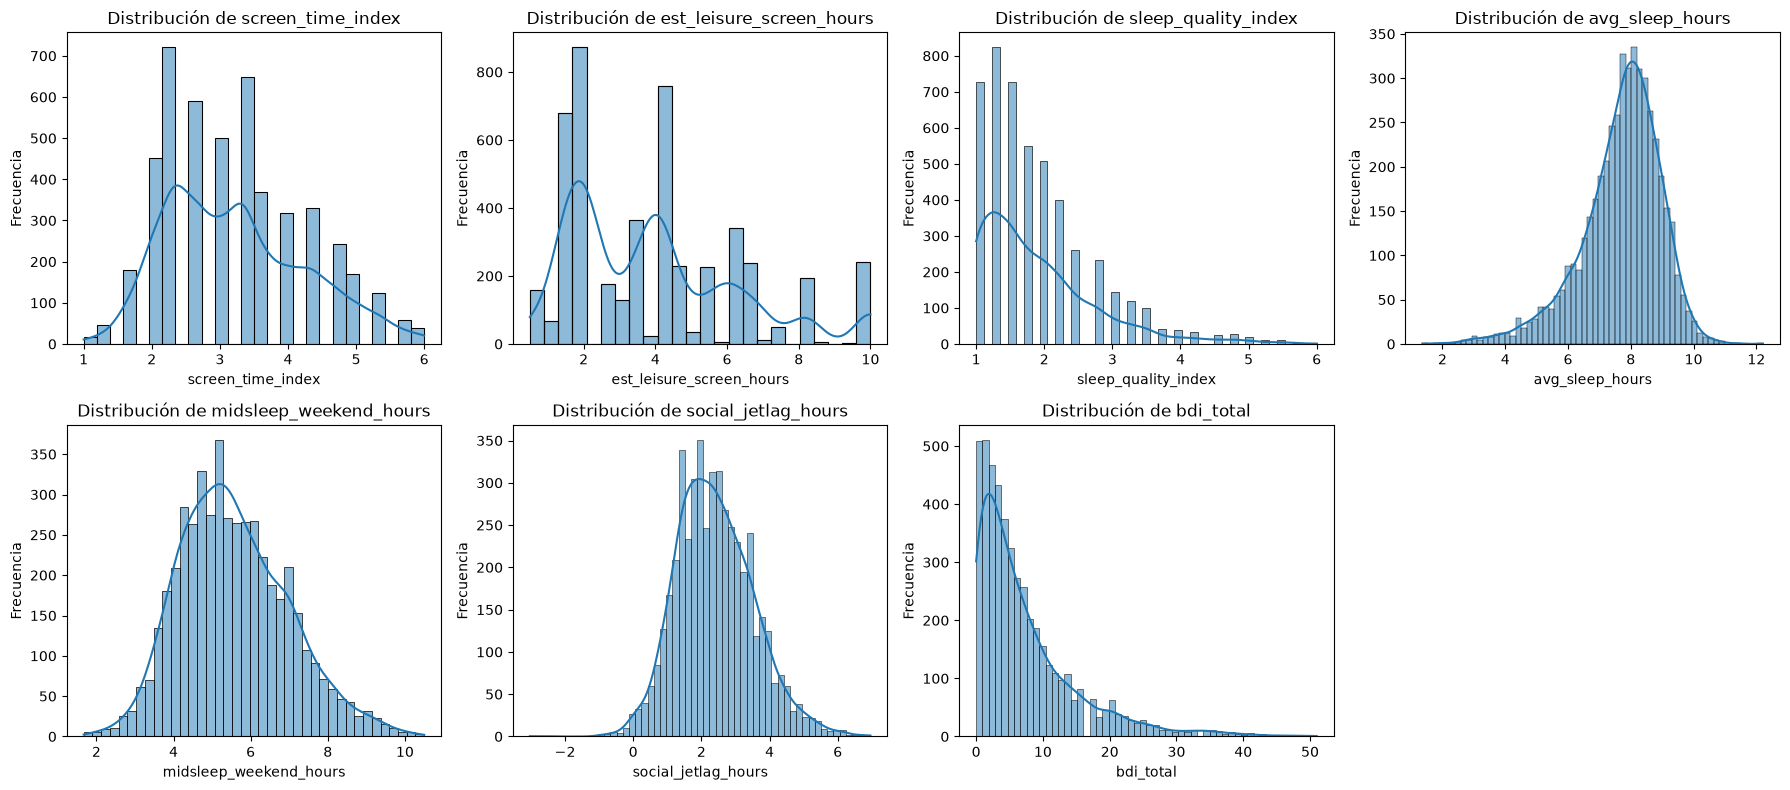

In [7]:
# Vamos a graficar los Histogramas

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for ax, variable in zip(axes.flatten(), variabless):

    sns.histplot(
        data=df,
        x=variable,
        kde=True,
        ax=ax
    )

    ax.set_title(f"Distribución de {variable}")
    ax.set_xlabel(variable)
    ax.set_ylabel("Frecuencia")

# Ocultar el último gráfico que queda vacío
axes[1, 3].set_visible(False)

plt.tight_layout()
plt.show()

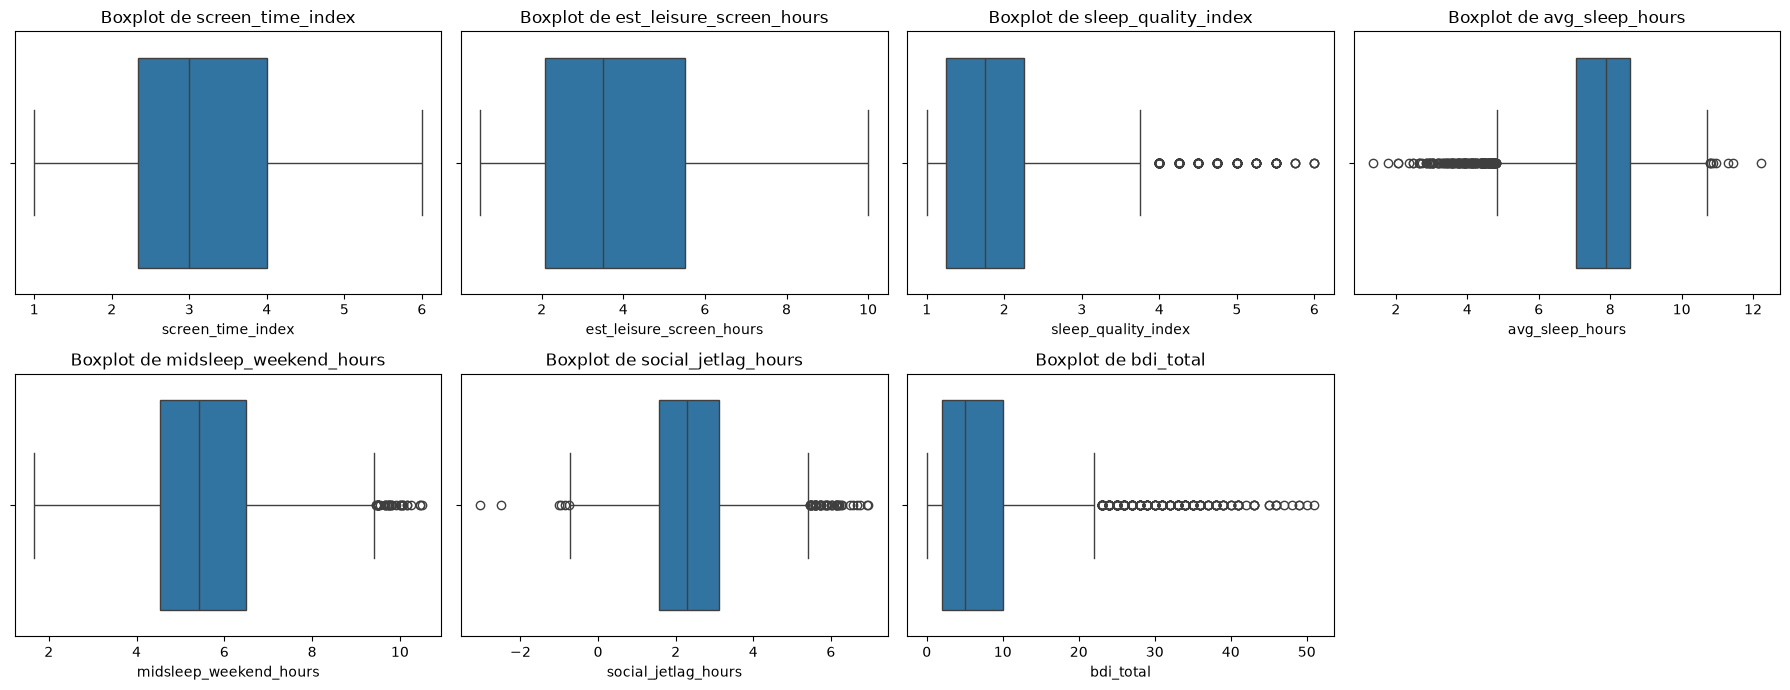

In [8]:
# BOXPLOTS

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 4, figsize=(18, 7))

for ax, variable in zip(axes.flatten(), variabless):

    sns.boxplot(
        data=df,
        x=variable,
        ax=ax
    )

    ax.set_title(f"Boxplot de {variable}")
    ax.set_xlabel(variable)

# Ocultar el último gráfico que queda vacío
axes[1, 3].set_visible(False)

plt.tight_layout()
plt.show()

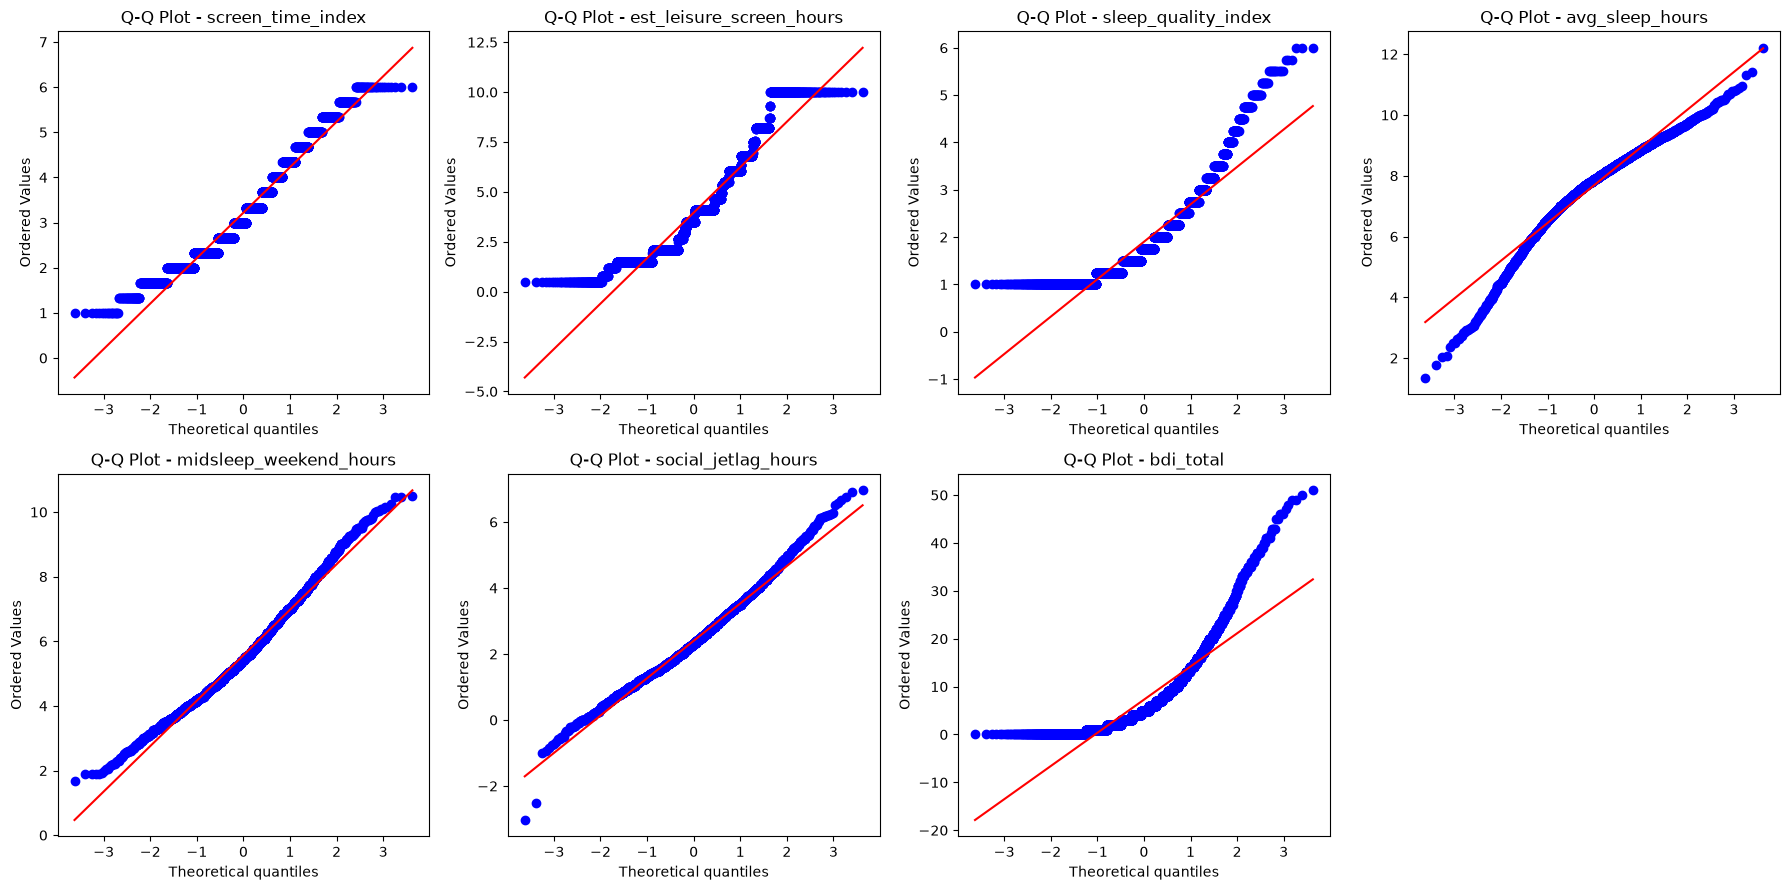

In [9]:
# Q-Q plots

import matplotlib.pyplot as plt
import scipy.stats as stats

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for ax, variable in zip(axes.flatten(), variabless):

    stats.probplot(
        df[variable].dropna(),
        dist="norm",
        plot=ax
    )

    ax.set_title(f"Q-Q Plot - {variable}")

# Ocultar el último espacio
axes[1, 3].set_visible(False)

plt.tight_layout()
plt.show()

- **screen_time_index:** distribución concentrada en valores intermedios, principalmente entre 2 y 4, con una ligera asimetría hacia la derecha. Hay pocos casos con niveles muy altos.


- **est_leisure_screen_hours:** distribución asimétrica a la derecha, concentrada aproximadamente entre 2 y 6 horas, pero con algunos individuos que alcanzan valores de hasta 10 horas.


- **sleep_quality_index:** distribución fuertemente asimétrica a la derecha. La mayoría presenta valores bajos (1–2,5), mientras que pocos casos alcanzan valores elevados.


- **avg_sleep_hours:** distribución aproximadamente unimodal y cercana a la normal, concentrada alrededor de 7–9 horas. Presenta una cola hacia valores bajos, coincidiendo con la asimetría negativa observada.


- **midsleep_weekend_hours:** distribución unimodal y relativamente simétrica, con mayor concentración alrededor de 5–6 horas. No se observan desviaciones extremas importantes.


- **social_jetlag_hours:** distribución aproximadamente simétrica y unimodal, concentrada alrededor de 2–3 horas. Presenta poca presencia de valores extremos.


- **bdi_total:** distribución fuertemente asimétrica a la derecha. La mayoría de los individuos presenta valores bajos de BDI, mientras que una cantidad reducida presenta valores elevados, llegando hasta aproximadamente 50. Esto evidencia posibles valores extremos.
Conclusión general

Las variables sleep_quality_index y especialmente bdi_total presentan las distribuciones más alejadas de la normalidad. En cambio, avg_sleep_hours, midsleep_weekend_hours y social_jetlag_hours muestran distribuciones más equilibradas. Las variables relacionadas con tiempo de pantalla presentan cierta concentración en valores bajos/medios y una cola hacia valores altos.

Y la variable **'sex'** que es categórica/binaria, por lo que la vamos a analizar con: Frecuencia absoluta, Porcentaje, Moda y Gráfico de barras.

In [10]:
# Frecuencias
print(df["sex"].value_counts())

# Porcentajes
print(df["sex"].value_counts(normalize=True) * 100)

# Moda
print("Moda:", df["sex"].mode()[0])

sex
Boy     2446
Girl    2364
Name: count, dtype: int64
sex
Boy     50.852391
Girl    49.147609
Name: proportion, dtype: float64
Moda: Boy


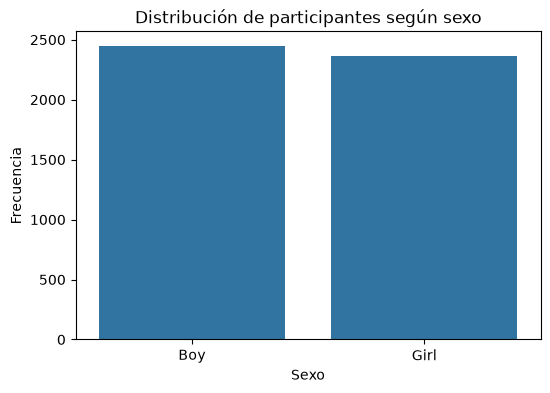

In [11]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="sex"
)

plt.title("Distribución de participantes según sexo")
plt.xlabel("Sexo")
plt.ylabel("Frecuencia")

plt.show()

En este caso ya sabemos que:

Boy: 2446 → 50,85%


Girl: 2364 → 49,15%

Por lo tanto, la distribución está muy equilibrada.

<Axes: xlabel='sex', ylabel='bdi_total'>

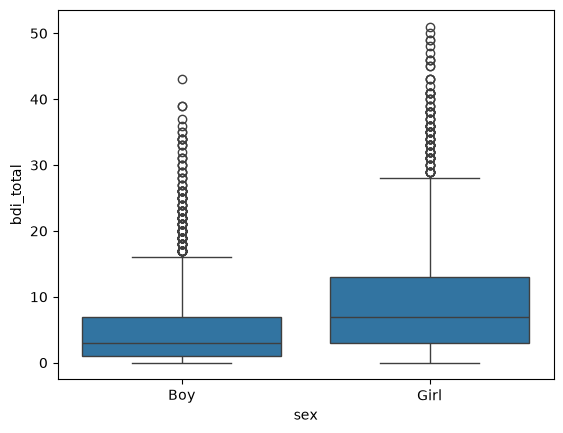

In [12]:
sns.boxplot(
    data=df,
    x="sex",
    y="bdi_total"
)

Contraste de hipótesis:

1. Diferencias de BDI según sexo:
¿El nivel promedio de síntomas depresivos difiere entre chicos y chicas?

H₀: no existen diferencias significativas en bdi_total entre los grupos.


H₁: existen diferencias significativas.

In [21]:
from scipy.stats import ttest_ind

boy = df[df["sex"] == 1]["bdi_total"]
girl = df[df["sex"] == 0]["bdi_total"]

resultado = ttest_ind(
    boy,
    girl,
    equal_var=False
)

print("Estadístico t:", resultado.statistic)
print("p-value:", resultado.pvalue)

Estadístico t: 19.402358948990706
p-value: 2.4603223067203074e-80



Estadístico t = 19,40 → es un valor muy alto, lo que indica una diferencia/efecto considerable respecto a la hipótesis nula.


p-value = 2,46 × 10⁻⁸⁰ → es muchísimo menor que 0,05.

**Conclusión: Se rechaza la hipótesis nula (H₀) y se concluye que existe una diferencia estadísticamente significativa entre los grupos/variables analizados.**
**El análisis mostró una diferencia estadísticamente significativa entre los grupos analizados (t = 19,40; p < 0,001). Por lo tanto, se rechaza la hipótesis nula, evidenciando una asociación significativa entre las variables estudiadas.**

2. Tiempo de pantalla y síntomas depresivos: ¿Las personas con mayor tiempo de pantalla presentan mayores niveles de BDI? ¿Existe una relación significativa entre las horas de pantalla recreativa y los síntomas depresivos? Si aumentan las horas de pantalla, ¿tienden también a aumentar los valores de BDI?

Variables:
est_leisure_screen_hours → horas estimadas de pantalla recreativa.
bdi_total → puntuación de síntomas depresivos.

H₀: no existe relación significativa entre est_leisure_screen_hours y bdi_total.

H₁: existe una relación significativa entre ambas variables.


In [24]:
from scipy.stats import spearmanr

rho, p_value = spearmanr(
    df["est_leisure_screen_hours"],
    df["bdi_total"]
)

print("Coeficiente de Spearman:", rho) # (rho) → indica la intensidad y dirección de la relación.
print("p-value:", p_value) # p-value → indica si la relación es estadísticamente significativa.

Coeficiente de Spearman: 0.11993204678187785
p-value: 7.075552933125157e-17


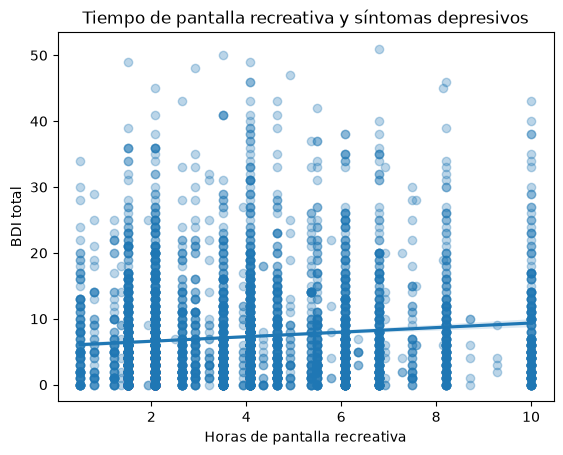

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(
    data=df,
    x="est_leisure_screen_hours",
    y="bdi_total",
    scatter_kws={"alpha": 0.3}
)

plt.title("Tiempo de pantalla recreativa y síntomas depresivos")
plt.xlabel("Horas de pantalla recreativa")
plt.ylabel("BDI total")

plt.show()

Contraste de hipótesis: Se analizó la relación entre las horas de pantalla recreativa y los síntomas depresivos mediante el coeficiente de correlación de Spearman, debido a la falta de normalidad de la variable bdi_total. Se planteó como hipótesis nula la ausencia de una relación significativa entre ambas variables y como alternativa la existencia de una relación significativa. Se utilizó un nivel de significancia de 0,05. El resultado se interpretó considerando tanto el coeficiente ρ como su p-value.

Los resultados de la correlación de Spearman son:

Coeficiente de Spearman (ρ) = 0,120: existe una correlación positiva muy débil entre las dos variables. Es decir, cuando una variable aumenta, la otra tiende a aumentar ligeramente, pero la relación es de baja intensidad.


p-value = 7,08 × 10⁻¹⁷: es mucho menor que 0,05, por lo que la correlación es estadísticamente significativa. Se rechaza la hipótesis nula de ausencia de relación.

Conclusión para nuestro análisis:

Se obtuvo una correlación de Spearman positiva y estadísticamente significativa entre las variables analizadas (ρ = 0,120; p < 0,001). Sin embargo, la magnitud de la correlación es muy baja, lo que indica que, aunque existe una asociación monotónica entre ambas variables, esta relación es débil. Por lo tanto, la significancia estadística no implica una asociación de gran relevancia práctica.

## Análisis de variables univariante

In [14]:
df["sex"].value_counts()

sex
Boy     2446
Girl    2364
Name: count, dtype: int64

In [15]:
df["sex"] = df["sex"].map({
    "Boy": 0,
    "Girl": 1
})

Tenemos que convertir nuestra variable categórica en numérica, porque un modelo de Regresión Lineal necesita trabajar valores numéricos. Como 'sex' tiene sólo dos categorías, la convertimos en una variable binaria. 

In [16]:
print(df["sex"].value_counts())

sex
0    2446
1    2364
Name: count, dtype: int64


Podemos ver que casi la mitad de las filas corresponden a encuestados de sexo masculino y el otro 50 a femenino. Hay un poco más de hombres encuestados, pero valores equilibrados de cada sexo. 

### Análisis sobre variables numéricas

Normalmente se representan utilizando un histograma y diagramas de caja, expuestos juntos. En nuestro Dataset todas las variables son numéricas, ya que a la única categórica ('sex') la transformamos y quedó categórica numérica (Girl/Boy). 

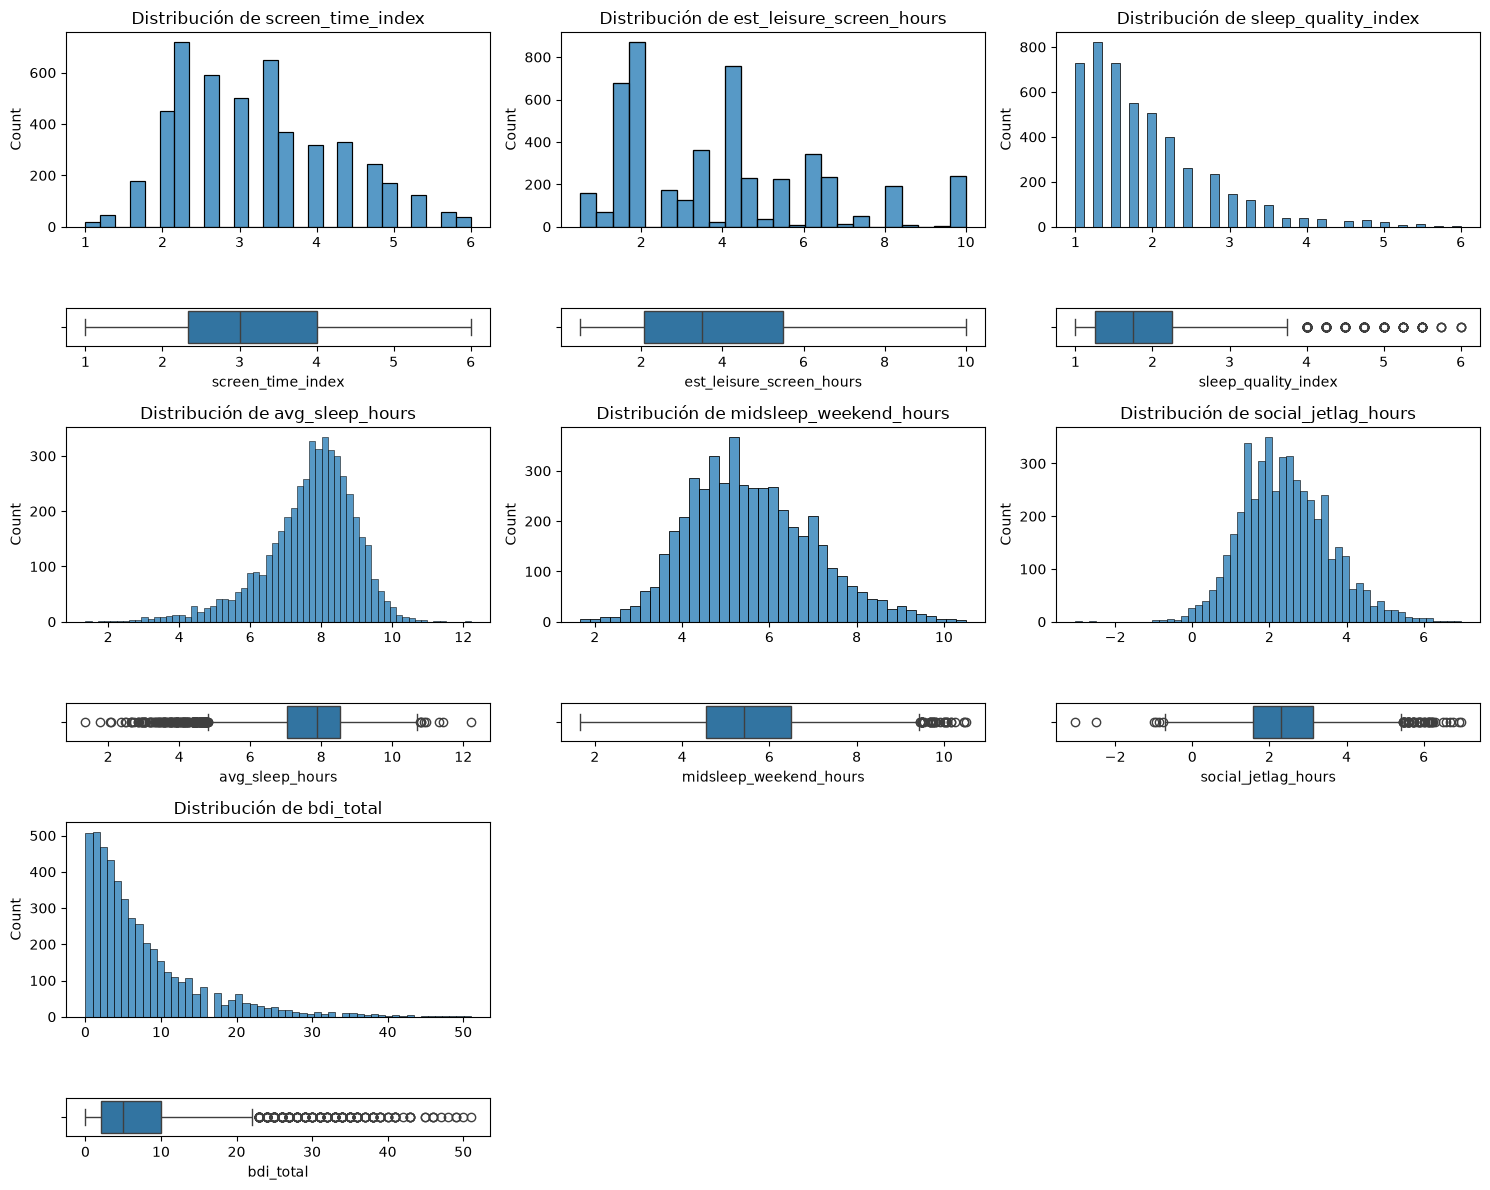

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

variables = [
    "screen_time_index",
    "est_leisure_screen_hours",
    "sleep_quality_index",
    "avg_sleep_hours",
    "midsleep_weekend_hours",
    "social_jetlag_hours",
    "bdi_total"
]

# 3 gráficos por fila
ncols = 3
nrows = (len(variables) + ncols - 1) // ncols

fig, axis = plt.subplots(
    nrows=2 * nrows,
    ncols=ncols,
    figsize=(15, 4 * nrows),
    gridspec_kw={"height_ratios": [5, 1] * nrows}
)

# Recorrer las variables
for i, variable in enumerate(variables):

    # Calcular fila y columna
    col = i % ncols
    row = (i // ncols) * 2

    # Histograma
    sns.histplot(
        data=df,
        x=variable,
        ax=axis[row, col]
    )

    axis[row, col].set_title(f"Distribución de {variable}")
    axis[row, col].set_xlabel("")
    
    # Boxplot
    sns.boxplot(
        data=df,
        x=variable,
        ax=axis[row + 1, col]
    )

    axis[row + 1, col].set_xlabel(variable)

# Ocultar espacios vacíos
for i in range(len(variables), nrows * ncols):
    col = i % ncols
    row = (i // ncols) * 2
    
    axis[row, col].set_visible(False)
    axis[row + 1, col].set_visible(False)

# Ajustar espacios
plt.tight_layout()

# Mostrar gráficos
plt.show()

- **screen_time_index:** presenta una distribución relativamente compacta/normal y no muestra una cantidad preocupante de valores atípicos.La distribución está bastante concentrada entre aproximadamente 2 y 4. Tiene cierta dispersión hacia valores mayores, llegando aproximadamente a 6. El boxplot no muestra una cantidad excesiva de valores atípicos. Por lo tanto, inicialmente parece una variable adecuada para utilizar como predictor en el modelo de regresión lineal.

- **est_leisure_screen_hours:** presenta una distribución multimodal, con concentraciones en determinados valores, No parece una distribución normal. Se observan concentraciones en distintos valores, especialmente alrededor de 2, 4, 6, 8 y 10 horas. Eso podría indicar que la variable está discretizada o que los datos fueron registrados en determinados intervalos. Esto no impide utilizarla como predictor en una regresión lineal, pero será necesario analizar posteriormente su relación con bdi_total para comprobar si existe una relación aproximadamente lineal. 

- **sleep_quality_index:** Esta variable presenta una distribución fuertemente asimétrica hacia la derecha. La mayoría de los valores están concentrados aproximadamente entre 1 y 3, mientras que hay algunos valores bastante mayores. Presenta una distribución asimétrica y una cantidad considerable de valores extremos. Estos valores deberán ser analizados para determinar si corresponden a observaciones válidas o a errores. No se recomienda eliminarlos automáticamente.

- **avg_sleep_hours:** Esta es una de las variables que visualmente presenta una distribución más cercana a una campana. La mayor concentración está aproximadamente alrededor de 7–9 horas.Hay personas con valores de sueño muy bajos y algunas con valores superiores a 10 horas. Sin embargo, el boxplot muestra valores extremos tanto por debajo como por encima del rango central. Presenta una distribución aproximadamente unimodal y relativamente cercana a una distribución normal, aunque existen algunos valores extremos. En principio, parece una variable adecuada para el modelo, pero los valores atípicos deberán ser revisados.

- **midsleep_weekend_hours:** Esta variable presenta una distribución bastante interesante. Tiene una concentración importante alrededor de 4–7 horas, con cierta asimetría hacia la derecha. El boxplot muestra varios valores extremos en la parte superior. Presenta una distribución relativamente continua, aunque con algunos valores extremos. Estos valores no deberían eliminarse automáticamente, ya que podrían representar horarios de sueño reales.

- **social_jetlag_hours:** La distribución tiene una forma aproximadamente unimodal, concentrándose alrededor de 1–3 horas. También presenta algunos valores negativos y valores extremos positivos. Esto tiene sentido conceptualmente porque el social jetlag representa la diferencia entre horarios de sueño y puede tomar distintos valores según cómo se haya calculado. Presenta una distribución relativamente concentrada, aunque existen valores extremos en ambos sentidos. Será necesario comprobar que dichos valores sean válidos y analizar posteriormente su relación con bdi_total.

- **bdi_total:** Esta es la variable más importante, porque es nuestra variable objetivo y. Y aquí encontramos algo que tenemos que destacar. La distribución está fuertemente sesgada hacia la derecha, hay una gran concentración de personas con valores bajos de bdi_total y cada vez menos observaciones a medida que aumenta el puntaje.
Además, el boxplot muestra numerosos valores que aparecen como outliers, llegando aproximadamente hasta 50.
Si bdi_total es un puntaje válido del instrumento utilizado, esos valores altos pueden representar personas con mayores niveles de síntomas. No son necesariamente errores.

Por lo tanto:

bdi_total presenta una distribución fuertemente asimétrica hacia la derecha y una cantidad importante de valores extremos. Debido a que estos valores representan puntajes reales del fenómeno estudiado, no deberían eliminarse automáticamente. Será necesario evaluar posteriormente su impacto sobre el modelo de regresión.






Y como ya vimos en el histograma más arriba en la parte de análisis descriptivo, la variable **'sex'** está bastante equilibrada, con una cantidad similar de observaciones en las categorías 0 y 1. Por lo tanto, no se observa un desbalance significativo que pueda afectar al modelo de regresión.

## Análisis de variables multivariante

Tras analizar las características una a una, es momento de analizarlas en relación con la predictora y con ellas mismas, para sacar conclusiones más claras acerca de sus relaciones y poder tomar decisiones sobre su procesamiento.

### Análisis numérico-numérico


Para comparar dos columnas numéricas se utilizan diagramas de dispersión y análisis de correlaciones.

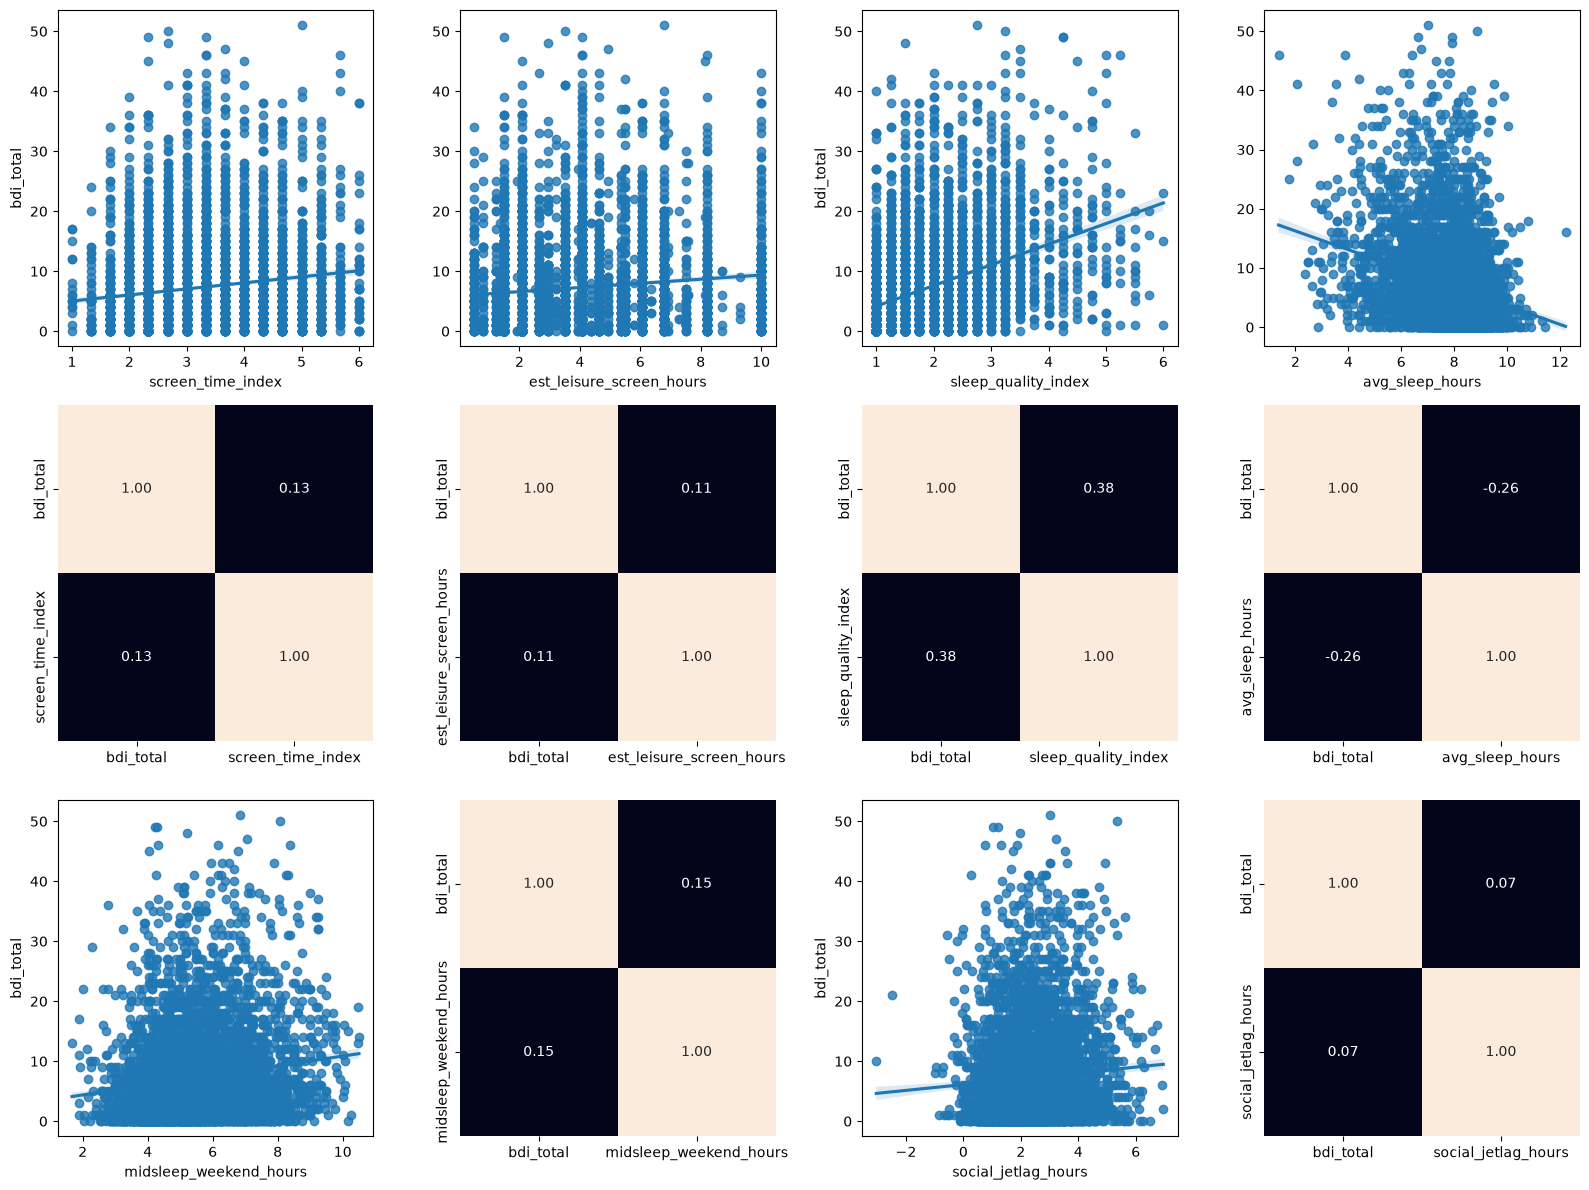

In [18]:
fig, axis = plt.subplots(3, 4, figsize=(16, 12))

# screen_time_index
sns.regplot(
    ax=axis[0, 0],
    data=df,
    x="screen_time_index",
    y="bdi_total"
)

sns.heatmap(
    df[["bdi_total", "screen_time_index"]].corr(),
    annot=True,
    fmt=".2f",
    ax=axis[1, 0],
    cbar=False
)

# est_leisure_screen_hours
sns.regplot(
    ax=axis[0, 1],
    data=df,
    x="est_leisure_screen_hours",
    y="bdi_total"
).set(ylabel=None)

sns.heatmap(
    df[["bdi_total", "est_leisure_screen_hours"]].corr(),
    annot=True,
    fmt=".2f",
    ax=axis[1, 1],
    cbar=False
)

# sleep_quality_index
sns.regplot(
    ax=axis[0, 2],
    data=df,
    x="sleep_quality_index",
    y="bdi_total"
)

sns.heatmap(
    df[["bdi_total", "sleep_quality_index"]].corr(),
    annot=True,
    fmt=".2f",
    ax=axis[1, 2],
    cbar=False
)

# avg_sleep_hours
sns.regplot(
    ax=axis[0, 3],
    data=df,
    x="avg_sleep_hours",
    y="bdi_total"
).set(ylabel=None)

sns.heatmap(
    df[["bdi_total", "avg_sleep_hours"]].corr(),
    annot=True,
    fmt=".2f",
    ax=axis[1, 3],
    cbar=False
)

# midsleep_weekend_hours
sns.regplot(
    ax=axis[2, 0],
    data=df,
    x="midsleep_weekend_hours",
    y="bdi_total"
)

sns.heatmap(
    df[["bdi_total", "midsleep_weekend_hours"]].corr(),
    annot=True,
    fmt=".2f",
    ax=axis[2, 1],
    cbar=False
)

# social_jetlag_hours
sns.regplot(
    ax=axis[2, 2],
    data=df,
    x="social_jetlag_hours",
    y="bdi_total"
)

sns.heatmap(
    df[["bdi_total", "social_jetlag_hours"]].corr(),
    annot=True,
    fmt=".2f",
    ax=axis[2, 3],
    cbar=False
)

# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

Los diagramas de correlación permiten identificar la dirección y la intensidad de la relación lineal entre las variables predictoras y el nivel de síntomas depresivos (bdi_total). Estas correlaciones sirven como análisis exploratorio previo al modelo de regresión, permitiendo detectar variables potencialmente relevantes y posibles problemas de multicolinealidad entre las predictoras.
 
Los diagramas de dispersión y las matrices de correlación muestran que ninguna de las variables predictoras presenta una relación lineal fuerte con bdi_total. La mayor asociación corresponde a sleep_quality_index (r = 0.38), seguida de avg_sleep_hours (r = -0.26). Las variables relacionadas con el uso de pantallas presentan correlaciones débiles (screen_time_index = 0.13; est_leisure_screen_hours = 0.11), mientras que social_jetlag_hours muestra una asociación prácticamente nula (r = 0.07). Estos resultados sugieren que las variables podrían aportar información al modelo de regresión de manera conjunta, aunque ninguna parece explicar por sí sola una proporción elevada de la variabilidad de los síntomas depresivos.


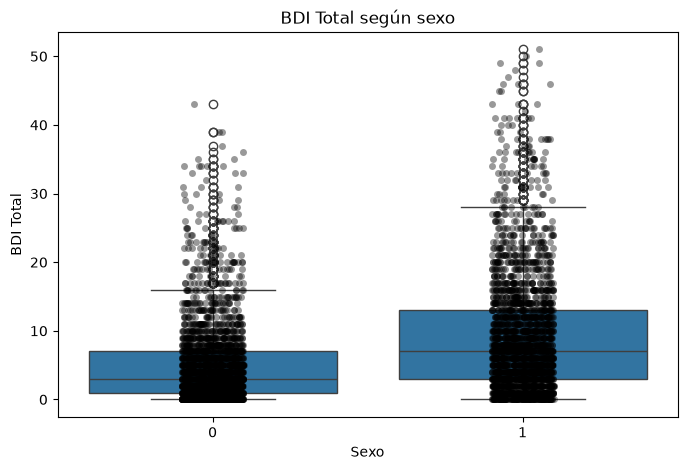

In [19]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="sex", y="bdi_total")
sns.stripplot(data=df, x="sex", y="bdi_total", color="black", alpha=0.4)

plt.title("BDI Total según sexo")
plt.xlabel("Sexo")
plt.ylabel("BDI Total")

plt.show()

Este diseño de boxplot nos permite mostrar los puntos individuales para ver mejor la distribución.

Se observa una diferencia en la distribución de bdi_total según el sexo. El grupo 0 (Girl) presenta una mediana de BDI Total más alta que el grupo 1 (Boy), aproximadamente 7 frente a 3 puntos.
Además, el grupo 0 muestra mayor dispersión, con valores de BDI más elevados y un rango intercuartílico más amplio.

Ambos grupos presentan numerosos valores atípicos altos, lo que indica que existen participantes con niveles de síntomas depresivos considerablemente superiores al resto.

El grupo 0 alcanza valores atípicos de BDI de aproximadamente 50 puntos, mientras que el grupo 1 llega hasta alrededor de 43.
Por lo tanto, sex podría ser una variable relevante para explicar bdi_total en el modelo de regresión, aunque sería necesario realizar un análisis estadístico para determinar si la diferencia observada es significativa.

**Conclusión: El boxplot muestra que existen diferencias en los niveles de bdi_total entre ambos grupos de sexo. El grupo 0 presenta una mediana y una variabilidad mayores, además de valores extremos más elevados. Esto sugiere que el sexo podría estar asociado con los síntomas depresivos y ser una variable potencialmente relevante para el modelo de regresión.**